# 2. Structure of the HDF5 output file

PlatoSim produces three output files:

* an **HDF5** file which is the subject of this notebook
* a **log** file which contains all info, warning, error, and debugging messages
* a copy of the **YAML** input file

We will assume in this notebook that you run PlatoSim and inspect the HDF5 output file from a python environment. The HDF5 file is located in the directory specified in `sim.outputDir`.

<img src="../../figures/PlatoSimStructureOfHDF5.png">

Shown in the figure above the first level shows the group `InputParameters` contains a copy of the configuration parameters from the YAML file. Every HDF5 output file has the Git version of the software saved should you need it.

The second level shows all the groups that contain image data for every exposure. These are the `Images`, `SmearingMaps`, `BiasMaps`, and `ThroughputMaps`.

The third level shows all the groups that contain single frame image data. These are the `PSF`, `BackgroundMap`, `FlatField`, and the `CTI`. Notice that the latter contains a map for each CTI trap specy that is included in the used model (hence 4 species for the Short model).

The fourth level shows all the groups that contains a mix of stellar parameters, payload parameters, and coordinates. The group `StarCatalog` contains the sky coordinates, the pixel coordinates, and the focal plane coordinates of all the stars that were detected during any exposure. The starIDs map the ID from the input starCatalog that is supplied with the configuration. 

The exact output structure of the groups `StarPositions`, `PointLikeGhostPositions`, `ExtendedGhostPositions`, and `Cosmics` depends on the YAML input entry called `GoupByExposure` when controlling what needs to be saved. By default every information is saved in folders per Exposure, however, if this parameter is False the information is saved per StarID. For long baseline simulations (more than 100,000 exposures), we recommend to use the latter option since this can significantly lower the computational resources (time and memory). Note that the information about the cosmic rays are never saved per star, however, it is saved into subfolder of 1000 exposures each.

In this tutorial we show how to inspect and extract information from the HDF5 output file produced by PlatoSim. We present how to use `h5py`, the in-build `h5` function, but we will place the effort on explaining how to fully utilise the in-build `SimFile` class.

Note: apart from the libraries show in this tutorial, it is also possible to investigate HDF(5) files with [PyTables](https://www.pytables.org/index.html), however, this packages is known to course problems with other packages used in PlatoSim and hence we avoid it for our dependencies.

### Setup notebook

In [1]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figures in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# PlatoSim
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

### Run a default simulation for the tutorial

In [3]:
# Define inputs and outputs
outputDir      = os.getcwd()
outputFileName = "output_example1"

# Generate simulation object and control the output
sim = Simulation(outputFileName, outputDir=outputDir)

# Point-like ghost included by default, include also extended ghosts
sim["Camera/IncludeExtendedGhosts"] = True

# Write PSFs to the output file
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True
sim["ControlHDF5Content/WriteSubPixelImages"]    = True

# Change sky background to pixel dependent
sim["Sky/SkyBackground/UseConstantSkyBackground"] = 'no'
sim["Sky/SkyBackground/BackgroundValue"]          = -1

# Group per exposure or per star
# NOTE that grouping per star is faster for long duration simulations
sim["ControlHDF5Content/GroupByExposure"] = True

# Select location of subfield on the CCD
sim["SubField/ZeroPointColumn"] = 1000
sim["SubField/ZeroPointRow"]    = 1000

# Run PlatoSim (and allow to overwrite output file)
sim.run(removeOutputFile=True);

---
## 2.1 - Inspect with [h5py](https://docs.h5py.org/en/stable/)
---

We here show a minimal example of using [h5py](https://docs.h5py.org/en/stable/) to inspect your HDF5 output file. E.g. let's fetch the first exposure simulated:

In [4]:
import h5py
h5file = h5py.File(outputFileName + '.hdf5', 'r')

In [5]:
# Get an image
im = h5file['Images/image0000000'][:]
im

array([[1079, 1082, 1080, ..., 1083, 1078, 1081],
       [1090, 1083, 1078, ..., 1070, 1080, 1080],
       [1086, 1084, 1081, ..., 1077, 1079, 1077],
       ...,
       [1084, 1077, 1081, ..., 1084, 1079, 1080],
       [1079, 1077, 1072, ..., 1082, 1079, 1079],
       [1075, 1079, 1082, ..., 1078, 1079, 1083]], dtype=uint16)

---
## 2.2 - Inspect with h5
---

PlatoSim has an build-in functionality to use `h5` to print the structure and fetch the information from the HDF5 output file:

In [6]:
from platosim.h5 import h5get, h5ls

### Function: h5ls

The function **h5ls** takes an HDF5 file object or a HDF5 group as a mandatory argument and shows the complete structure of the HDF5 file or group. Each level is indicated by the following type acronyms, and for attributes their value is shown.

[G] Group <br/>
[D] Dataset <br/>
[a] Attribute

Print the entire HDF5 file - equivalent to specifying only the root group `h5ls(h5file['/'])`:

In [7]:
h5ls(h5file)

[G] /ACS
[D]     /pitch
[D]     /platformDec
[D]     /platformRA
[D]     /roll
[D]     /time
[D]     /yaw
[G] /BackgroundMap
[D]     /skyBackground
[G] /BiasMapsLeft
[D]     /biasMap0000000
[D]     /biasMap0000001
        ...
[D]     /biasMap0000009
[G] /BiasMapsRight
[D]     /biasMap0000000
[D]     /biasMap0000001
        ...
[D]     /biasMap0000009
[G] /CTI
[D]     /trapDensityMapForSpecies0BOL
[D]     /trapDensityMapForSpecies0EOL
        ...
[D]     /trapDensityMapForSpecies3EOL
[G] /Cosmics
[G]     /BiasMapLeft
[G]         /Exposure0000000
[D]             /columns
[D]             /entryAngles
[D]             /entryColumns
[D]             /entryRows
[D]             /flux
[D]             /intensities
[D]             /rows
[D]             /trailLengths
[G]         /Exposure0000001
[D]             /columns
[D]             /entryAngles
[D]             /entryColumns
[D]             /entryRows
[D]             /flux
[D]             /intensities
[D]             /rows
[D]             /trail

In [8]:
# Example of a Dataset
h5ls(h5file['BiasMapsLeft'])

[D] /biasMap0000000
[D] /biasMap0000001
    ...
[D] /biasMap0000009


In [9]:
# Example of attributes
h5ls(h5file['InputParameters/CCD/Gain'])

[a] /AllowedDifference      15.0
[a] /     RefValueLeft      2.14
[a] /    RefValueRight      2.21
[a] /        Stability      -0.001


### Function: h5get

With **h5get** you can get data out of the HDF5 file into numpy arrays or python variables. This function takes two mandatory arguments, the HDF5 file object (or group) and the 'path into the variable or dataset'.

When you specify the full path, only that variable is returned as shown in the following two commands. When you specify a partial path or just the name of the final dataset/attribute, the **h5get** function looks for all possible matches and returns an array with their values. This is illustrated further with 'ReadoutNoise'.

In [10]:
pos = h5get(h5file, "/InputParameters/CCD/Position", verbose=False)
print(f"Type and value of Position: {type(pos)}, {pos}")

Type and value of Position: <class 'str'>, Custom


In [11]:
noise = h5get(h5file, "/InputParameters/CCD/ReadoutNoise", verbose=False)
print(f"Type and value of ReadoutNoise: {type(noise)}, {noise}")

Type and value of ReadoutNoise: <class 'numpy.float64'>, 38.7


In [12]:
h5get(h5file, "ReadoutNoise")

selection strings: ['ReadoutNoise']
matching items:
    Attribute       /InputParameters/CCD/IncludeReadoutNoise
    Attribute       /InputParameters/CCD/ReadoutNoise
    Attribute       /InputParameters/FEE/ReadoutNoise
    Attribute       /InputParameters/RandomSeeds/ReadOutNoiseSeed


[1, 38.7, 32.0, 1424949740]

In [13]:
cols = h5get(h5file, "InputParameters/CCD/NumColumns", verbose=False)
print ("Type and value of NumColumns: {}, {}".format(type(cols), cols))

Type and value of NumColumns: <class 'numpy.int32'>, 4510


In [14]:
dec = h5get(h5file, "ACS/PlatformDec", verbose=False)
ra  = h5get(h5file, "ACS/PlatformRA", verbose=False)
print ("Type and shape of RA : {}, {}".format(type(ra), ra.shape))
print ("Type and shape of Dec: {}, {}".format(type(dec), dec.shape))

Type and shape of RA : <class 'numpy.ndarray'>, (10,)
Type and shape of Dec: <class 'numpy.ndarray'>, (10,)


In [15]:
im = h5get(h5file,"Images/image0000000", verbose=False)
im

array([[1079, 1082, 1080, ..., 1083, 1078, 1081],
       [1090, 1083, 1078, ..., 1070, 1080, 1080],
       [1086, 1084, 1081, ..., 1077, 1079, 1077],
       ...,
       [1084, 1077, 1081, ..., 1084, 1079, 1080],
       [1079, 1077, 1072, ..., 1082, 1079, 1079],
       [1075, 1079, 1082, ..., 1078, 1079, 1083]], dtype=uint16)

---
## 2.3 - Inspect with SimFile
---

In the previous tutorials we already touched upon how you can use the PlatoSim `SimFile` class to retrieve information from the HDF5 output file. Here we dive in a bit deeper and show most of its functionalites. 

A few notes:
- All functions automatically access which camera (*Normal* or *Fast*) that has been used in the simulation.
- Many of the following functionalities it is possible to add the time column of the camera cadence by parsing the flag `getTime=True`. Look out for when this is applicable in the following. 
- By default the help functions of `SimFile` return numpy arrays wherever applicable, however, to make the data handling more user friendly it is also possible to parse the flag `df=True` to return a Pandas data frame. 

First let's get the HDF5 file with:

In [16]:
f = SimFile(outputFileName + ".hdf5")

`reload()`: If you accidentially overwrites/mess up some parameters, you can always reload the HDF5 output again using: 

In [17]:
f.reload()

For the sake of this tutorial we will only inspect the first exposure, hence:

In [18]:
imageNr = 0

### Input Parameters

`getInputParameter()`: We here give a minimal example to show how to inspect one of the input parameters that was used for the simulation. The group name and parameter name are exactly the same as in the YAML file. E.g. fetch the `CycleTime`:

In [19]:
f.getInputParameter("ObservingParameters", "CycleTime")

25.0

`getExposureTime()`: Get the exposure time:

In [20]:
t_exp = f.getExposureTime()
t_exp

20.996628

`getReadoutTime()`: Get the readout time before the next exposure starts and the readout time during the next exposure:

In [21]:
t_out_before, t_out_after = f.getReadoutTime()
t_out_before, t_out_after

(4.003372000000001, 0)

``getTime()``: Get time column of all exposures - Note that this is a Pandas data frame:

In [22]:
time = f.getTime(df=True)
time

,time
0,0.0
1,25.0
2,50.0
3,75.0
4,100.0
5,125.0
6,150.0
7,175.0
8,200.0
9,225.0


### Pointing, Jitter, and Drift

Below we show how to fetch information from the `Platform` and `Telescope` group in the HDF5 file. Both of groups share the same data structure of corresponding columns, hence, below we simple show the functionalities for the platform. Simple replace "Platform" with "Telescope" in the respective function name to fetch information about the telescope.

`getPlatformInfo()`: Get all the columns stored in the platform group:

In [23]:
f.getPlatformInfo(df=True).head()

,time,alpha,delta,yaw,pitch,roll
0,0.0,86.800000,-46.400000,0.000000,0.000000,0.000000
1,25.0,86.799995,-46.399997,-0.007383,0.014755,-0.009974
2,50.0,86.800007,-46.399995,-0.016985,-0.013432,-0.021047
3,75.0,86.800001,-46.399992,-0.007113,0.002358,-0.029845
4,100.0,86.800001,-46.399991,-0.006687,0.001435,-0.033490


 `getPlatformYawPitchRoll()`: Get the platform rotation angles (yaw, pitch, roll):

In [24]:
df = f.getPlatformYawPitchRoll(getTime=True, df=True)

<IPython.core.display.Javascript object>


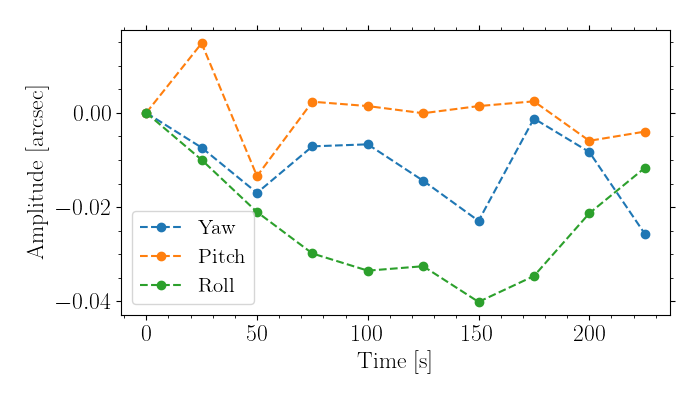

In [25]:
plt.figure(figsize=(7,4))
exp = np.arange(1,11,1)
plt.plot(df.time, df.yaw,   'o--', label="Yaw")
plt.plot(df.time, df.pitch, 'o--', label="Pitch")
plt.plot(df.time, df.roll,  'o--', label="Roll")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [arcsec]")
plt.tight_layout()
plt.legend();

`getPlatformPointingCoordinates()`: Get the platform jitter in either equatorial coordinates (RA, Dec):

In [26]:
alpha, delta = f.getPlatformPointingCoordinates()

# Convert to relative pointing coordinates [deg -> arcsec]
alphaMean = (alpha-np.mean(alpha)) * 3600
deltaMean = (delta-np.mean(delta)) * 3600

<IPython.core.display.Javascript object>


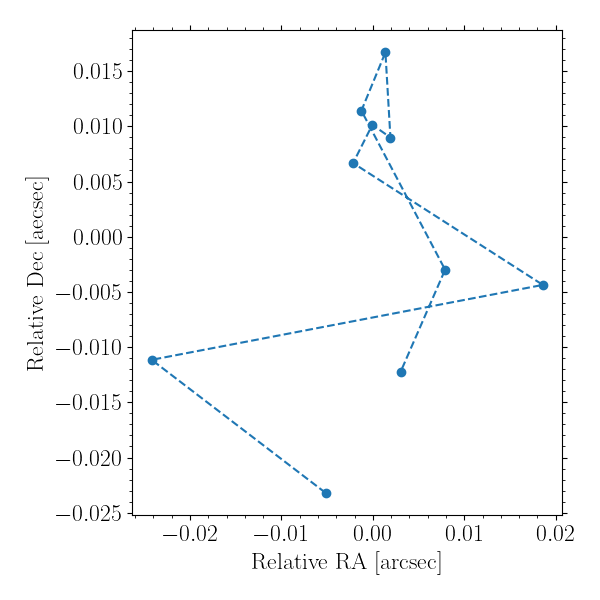

In [27]:
plt.figure(figsize=(6,6))
plt.plot(alphaMean, deltaMean, 'o--')
plt.xlabel("Relative RA [arcsec]")
plt.ylabel("Relative Dec [aecsec]")
plt.ticklabel_format(useOffset=False) 
plt.tight_layout()
plt.show()

### Ghosts

`getPointLikeGhostCoordinates()`: Get information about the point-like ghosts:

In [28]:
f.getPointLikeGhostCoordinates(imageNr, df=True).head()

,ID,row,col,xFP,yFP,flux
0,43639,13.736740,99.139107,19.784504,18.247261,2650.0
1,43785,91.048108,81.854027,19.473372,19.638866,27.0
2,43992,19.591151,70.937231,19.276870,18.352641,31.0
3,44022,96.821279,62.994958,19.133909,19.742783,55.0
4,44109,68.194708,56.470650,19.016472,19.227505,20.0


`getExtendedGhostCoordinates()`: Get information about extended ghosts:

In [29]:
f.getExtendedGhostCoordinates(imageNr, df=True).head()

,ID,row,col,xFP,yFP,flux,radius
0,76551,102.106242,52.635987,18.947448,19.837912,168.0,1.929439
1,76711,159.731563,53.382403,18.960883,20.875168,469.0,1.938994
2,76783,49.194854,80.577343,19.450392,18.885507,129.0,1.925544
3,76988,163.278959,75.125025,19.352250,20.939021,660.0,1.942975
4,77072,167.476281,80.141174,19.442541,21.014573,567.0,1.944483


### Cosmic rays

`getCosmicsInfo()`: You can also retrieve information about the cosmic rays added to each exposure. Since cosmic rays can be added to several image products, note that the `field` parameters can determines from what field the Cosmics should be returned: `SubField`, `BiasMapLeft`, `BiasMapRight` or `SmearingMap`. We here fetch the cosmic ray information for exposure 0 in the star image:

In [30]:
f.getCosmicsInfo(imageNr, field="SubField", df=True)

,entryRows,entryColumns,entryAngles,intensities,trailLengths
0,98,18,0.444378,2713.427973,13.509322
1,92,92,5.277555,2846.336240,2.590430
2,12,93,0.762330,2757.060972,12.834314
3,98,47,3.577089,4672.497000,9.135534
4,23,31,2.746141,4027.235835,8.963343
5,39,15,0.117797,2848.273735,2.121963
6,38,69,0.255290,4900.921006,3.367589
7,66,11,1.557528,2686.061344,10.476304
8,92,48,0.587801,6426.908117,13.547678


`getCosmicsAffectedPixels()`: Get knowledge about the pixels that are affected by cosmic rays in the subfield:

In [31]:
f.getCosmicsAffectedPixels(imageNr, df=True).head()

,row,col,flux
0,98,18,580.029792
1,98,19,485.124574
2,98,20,57.266166
3,99,20,374.030591
4,99,21,381.996555


### Stellar information

`getStarCatalog()`: Get the catalogue containing the stars that have been detected on a CCD:

In [32]:
f.getStarCatalog(df=True).head()

,ID,ra,dec,mag,xFP,yFP,xPix,yPix
0,43639,92.365377,-51.389250,7.108,-19.784523,-18.247422,-1099.140145,-1013.745676
1,43785,92.880797,-51.339206,11.957,-19.473380,-19.639025,-1081.854454,-1091.056958
2,43992,92.418754,-51.275672,11.965,-19.276888,-18.352798,-1070.938196,-1019.599873
3,44022,92.927809,-51.263596,11.225,-19.133916,-19.742940,-1062.995334,-1096.829985
4,44109,92.744005,-51.229641,12.380,-19.016482,-19.227660,-1056.471237,-1068.203352


`getStarCoordinates()`: Get the stellar coordinates in the CCD focal plane (both in pixel and mm). It is also possible to only get the coordinates of stars within a certain magnitude range `[minMag, maxMag]` as we show in the following for exposre 0:

In [33]:
df = f.getStarCoordinates(imageNr, minMag=None, maxMag=None, df=True)
df.head()

,ID,row,col,xFP,yFP,flux
0,76988,92.280712,9.507066,18.171127,19.661053,1101179.0
1,77072,96.221860,14.217065,18.255907,19.731993,945057.0
2,77214,86.270759,26.822338,18.482802,19.552874,107909.0
3,77241,10.770239,43.909970,18.790379,18.193864,177442.0
4,77521,75.965361,52.629926,18.947339,19.367377,726203.0


`getStarPosition()`: Get the stellar pixel coordinates only for a specific target star ID:

In [34]:
f.getStarPositions(df.ID.iloc[0], getTime=True, df=True)

,time,row,col
0,0.0,92.280712,9.507066
1,25.0,92.279744,9.506344
2,50.0,92.281690,9.505564
3,75.0,92.280568,9.505012
4,100.0,92.280626,9.504769
5,125.0,92.280768,9.504792
6,150.0,92.280702,9.504235
7,175.0,92.280531,9.504720
8,200.0,92.281141,9.505587
9,225.0,92.281100,9.506143


### Subfield images

`getImage()`: Get the full simulated subfield and the image dimentions and use them as extentions:

In [35]:
image      = f.getImage(imageNr)
numRows    = f.getInputParameter("SubField", "NumRows")
numColumns = f.getInputParameter("SubField", "NumColumns")

`showMap()`: We additionally provide a small quicklook tool that can be used to plot any pixel map:

<IPython.core.display.Javascript object>


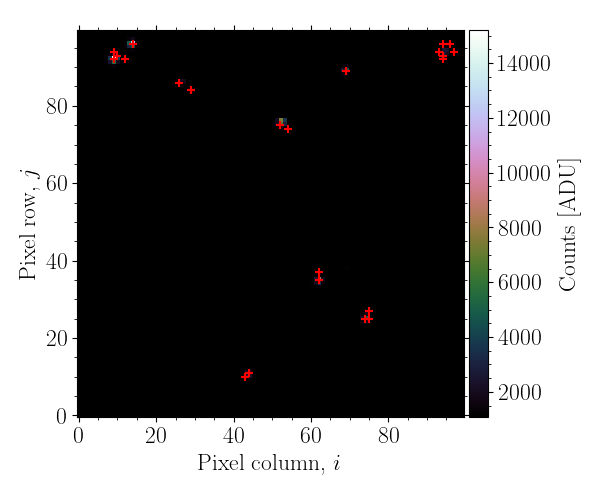

In [36]:
fig, ax = f.showMap(image, figsize=(6,5))
ax.scatter(np.floor(df.col), np.floor(df.row), marker='+', c='r');

Due the large dynamic range in pixel counts, this is unfortunately not well suited for larger subfields. Another options is to use the build-in function `showImage()` to visualize your subfield together with the stellar coordinates:

<IPython.core.display.Javascript object>


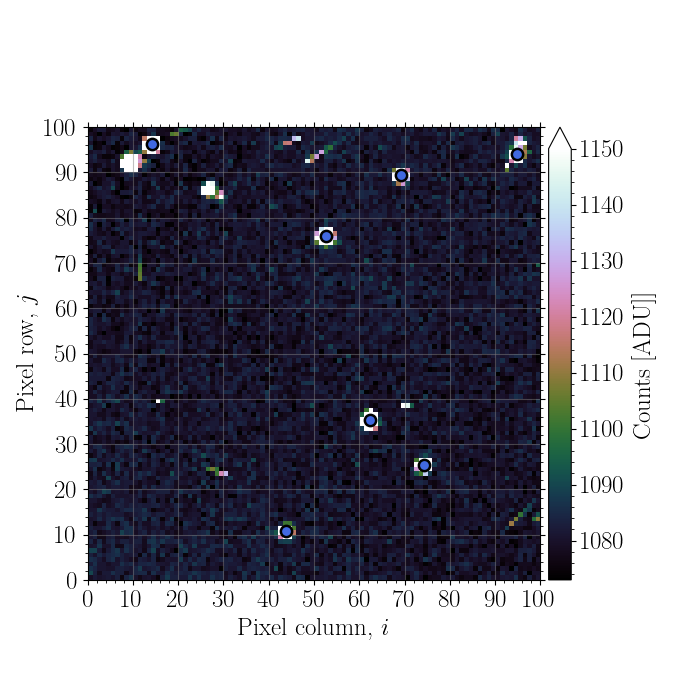

In [37]:
fig, ax = f.showImage(imageNr, imgScale="percentile", clip=1,
                      minMag=10.0, maxMag=12.0,
                      figsize=(7,7), fontSize=18, useTitle=False,
                      showStarPositions=True, showStarIDs=False,
                      colorMap="cubehelix", colorBar=True, showGrid=True)

`getImagette()`: It is also possible to fetch a smaller subfield (known as an *imagette*) around a given target star. Here we first find all the star IDs and select a subfield with radius of 3 pixels:

In [38]:
imagette = f.getImagette(df.ID.iloc[0], imageNr, radius=3)

<IPython.core.display.Javascript object>


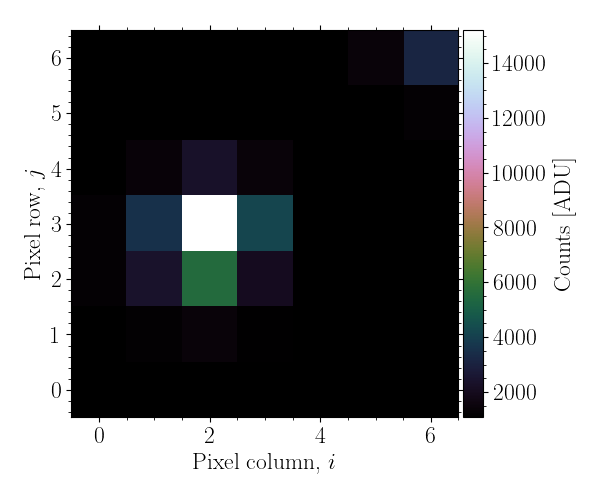

In [39]:
f.showMap(imagette, figsize=(6,5));

### Point Spred Function (PSF)

`getPSF()`: The PSF can also be fetched. Above we saved the high resolution PSF to file, but it is also possible to save the diffused PSF. Here we fetch the following:

In [40]:
psf = f.getPSF("highResPSF")

`showPSF()`: Again there is an in-build function to show the used PSF:

<IPython.core.display.Javascript object>


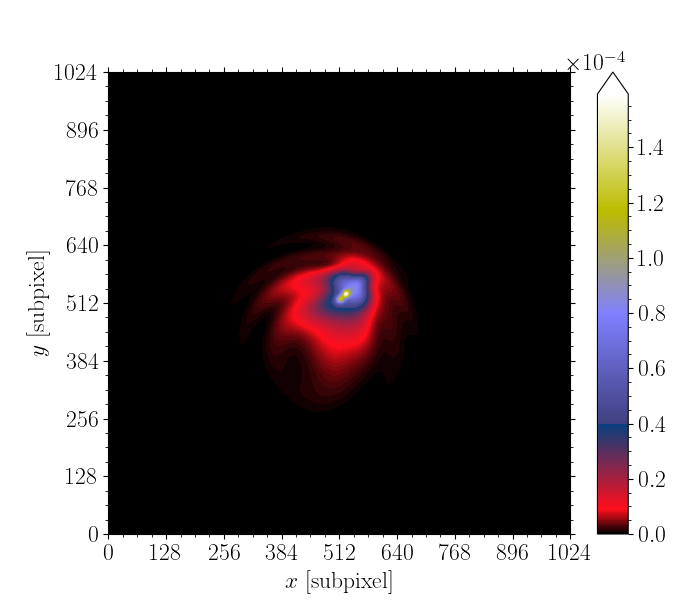

In [41]:
fig, ax = f.showPSF("highResPSF");

### Remaing pixel maps

`getSmearingMap()`: The smearing map (from a parallel overscan) can be fetched with:

In [42]:
sm = f.getSmearingMap(imageNr)

<IPython.core.display.Javascript object>


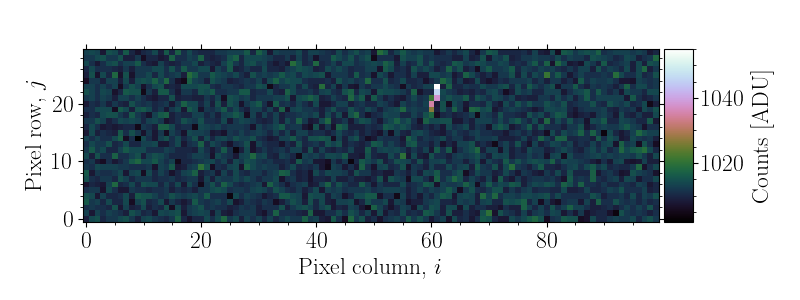

In [43]:
f.showMap(sm, figsize=(8,3));

`getBiasMapLeft()` and `getBiasMapRight()`: Get the bias map (from a serial prescan) for the left and right CCD half, respectively:

In [44]:
bm_left, bm_right = f.getBiasMapLeft(imageNr), f.getBiasMapRight(imageNr)

<IPython.core.display.Javascript object>


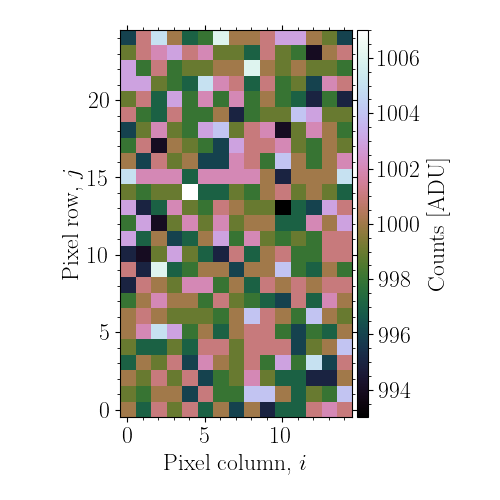

<IPython.core.display.Javascript object>


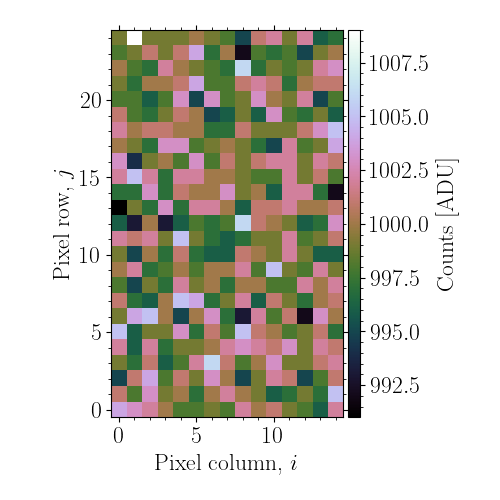

In [45]:
f.showMap(bm_left, figsize=(5,5))
f.showMap(bm_right, figsize=(5,5));

`getSkyBackgroun()`: The sky background map can be fetched with:

In [46]:
bg = f.getBackground()

<IPython.core.display.Javascript object>


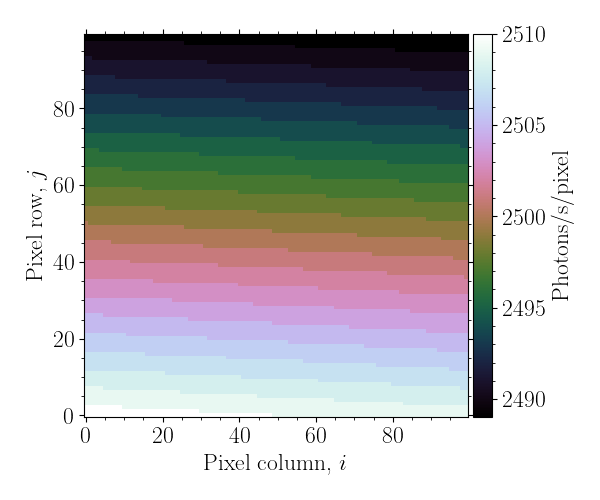

In [47]:
f.showMap(bg, figsize=(6,5), clabel='Photons/s/pixel');

 `getThroughputMap()`: Get the throughput map:

In [48]:
tm = f.getThroughputMap(imageNr)

<IPython.core.display.Javascript object>


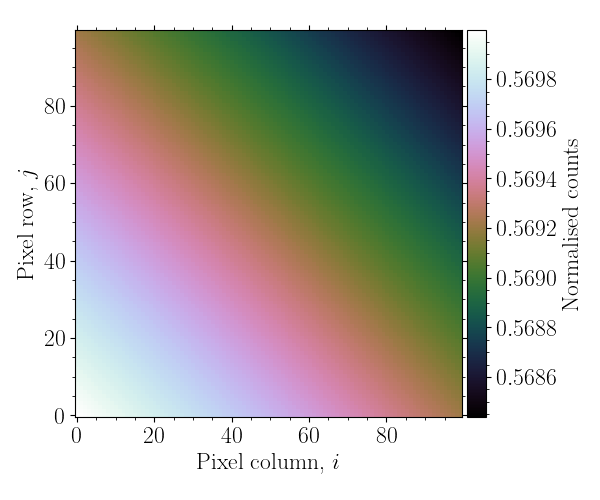

In [49]:
f.showMap(tm, figsize=(6,5), clabel='Normalised counts');

`getPRNU()`: Get the Pixel Response Non-Uniformity (PRNU; which essentially is the flat-field image):

In [50]:
prnu = f.getPRNU()

<IPython.core.display.Javascript object>


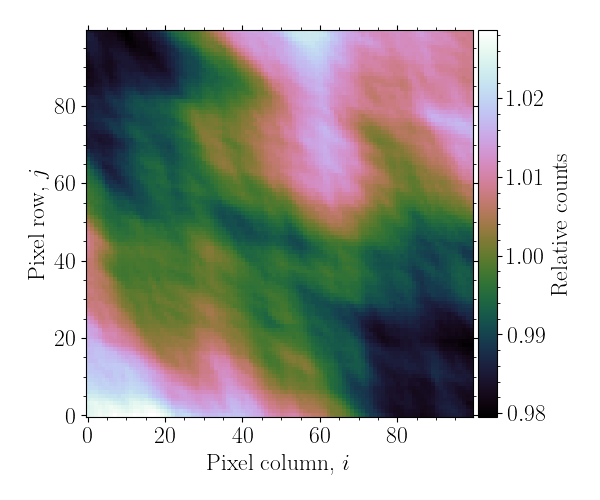

In [51]:
f.showMap(prnu, figsize=(6,5), clabel='Relative counts');